In [ ]:
!pip install datasets lxml cairosvg sentencepiece tokenizers tqdm matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 4.6 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset

# Load datasets
icons = load_dataset("starvector/svg-icons-simple", split="train")
emoji = load_dataset("starvector/svg-emoji-simple", split="train")

# IMPORTANT: sample large datasets (otherwise too big)
stack = load_dataset("starvector/svg-stack-simple", split="train[:10%]")

# Combine
all_data = list(icons) + list(emoji) + list(stack)

print("Total raw samples:", len(all_data))

Total raw samples: 207511


### Clean + Normalize SVGs

In [ ]:
import re

def clean_svg(svg):
    svg = re.sub(r'<!--.*?-->', '', svg, flags=re.DOTALL)
    svg = re.sub(r'<metadata.*?</metadata>', '', svg, flags=re.DOTALL)
    svg = re.sub(r'\s+', ' ', svg).strip()
    return svg

def round_numbers(svg):
    return re.sub(
        r'(\d+\.\d+)',
        lambda x: str(round(float(x.group()), 1)),
        svg
    )

### Validate + Filter
 Must include:
 - length filter
- XML validation
- rendering validation

In [ ]:
from lxml import etree
import cairosvg

MIN_CHARS = 50
MAX_CHARS = 2000

def is_valid_svg(svg):
    try:
        etree.fromstring(svg.encode('utf-8'))
        return True
    except:
        return False

def renders(svg):
    try:
        cairosvg.svg2png(bytestring=svg.encode('utf-8'))
        return True
    except:
        return False

def filter_svg(svg):
    if len(svg) < MIN_CHARS:
        return False
    if len(svg) > MAX_CHARS:
        return False
    if not is_valid_svg(svg):
        return False
    if not renders(svg):
        return False
    return True

In [ ]:
# pipeline
from tqdm import tqdm

cleaned_svgs = []

for item in tqdm(all_data):
    svg = item["Svg"]

    svg = clean_svg(svg)
    svg = round_numbers(svg)

    if filter_svg(svg):
        cleaned_svgs.append(svg)

print("After filtering:", len(cleaned_svgs))

100%|██████████| 207511/207511 [12:18<00:00, 281.09it/s]

After filtering: 134263


In [ ]:
import random

random.shuffle(cleaned_svgs)

n = len(cleaned_svgs)

train_svgs = cleaned_svgs[:int(0.98 * n)]
val_svgs   = cleaned_svgs[int(0.98 * n):int(0.99 * n)]
test_svgs  = cleaned_svgs[int(0.99 * n):]

### Train tokenizer

In [ ]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

tokenizer = Tokenizer(models.BPE())

trainer = trainers.BpeTrainer(
    vocab_size=4000,
    special_tokens=["<pad>", "<unk>", "<bos>", "<eos>"]
)

tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel()

tokenizer.train_from_iterator(train_svgs, trainer)

tokenizer.save("svg_tokenizer.json")

pad_id = tokenizer.token_to_id("<pad>")
print("Vocab size:", tokenizer.get_vocab_size())
print("Pad ID:", pad_id)

Vocab size: 4000
Pad ID: 0


In [ ]:
from tqdm import tqdm

MAX_TOKENS = 1024

train_tokens = []
for svg in tqdm(train_svgs):
    tokens = tokenizer.encode(svg).ids
    if len(tokens) <= MAX_TOKENS:
        train_tokens.append(tokens)

val_tokens = []
for svg in tqdm(val_svgs):
    tokens = tokenizer.encode(svg).ids
    if len(tokens) <= MAX_TOKENS:
        val_tokens.append(tokens)

test_tokens = []
for svg in tqdm(test_svgs):
    tokens = tokenizer.encode(svg).ids
    if len(tokens) <= MAX_TOKENS:
        test_tokens.append(tokens)

100%|██████████| 1343/1343 [00:04<00:00, 327.87it/s]


In [ ]:
train = train_tokens
val   = val_tokens
test  = test_tokens

In [ ]:
import torch

In [ ]:
torch.save(train_tokens, "train_tokens.pt")
torch.save(val_tokens, "val_tokens.pt")
torch.save(test_tokens, "test_tokens.pt")

In [ ]:
train_tensor = [torch.tensor(x, dtype=torch.long) for x in train_tokens]
val_tensor   = [torch.tensor(x, dtype=torch.long) for x in val_tokens]
test_tensor  = [torch.tensor(x, dtype=torch.long) for x in test_tokens]

torch.save(train_tensor, "train_tokens.pt")

## Dataset Statistics

In [ ]:
def count_tokens(data):
    return sum(len(x) for x in data)

print("Train tokens:", count_tokens(train))
print("Val tokens:", count_tokens(val))
print("Test tokens:", count_tokens(test))

print("Total tokens:", count_tokens(train) + count_tokens(val) + count_tokens(test))

Train tokens: 73203102
Val tokens: 754253
Test tokens: 735887
Total tokens: 74693242


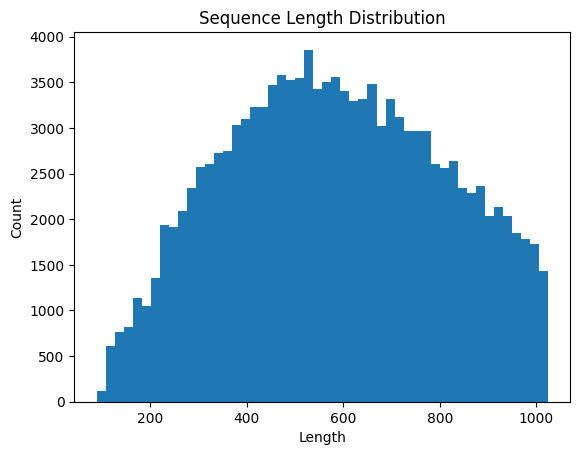

In [ ]:
import matplotlib.pyplot as plt

lengths = [len(x) for x in train]

plt.hist(lengths, bins=50)
plt.title("Sequence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

### Render Examples

In [ ]:
import cairosvg

# sort by length for complexity
sorted_svgs = sorted(cleaned_svgs, key=len)

samples = [
    sorted_svgs[10],                     # simple
    sorted_svgs[len(sorted_svgs)//2],   # medium
    sorted_svgs[-10]                    # complex
]

for i, svg in enumerate(samples):
    cairosvg.svg2png(bytestring=svg.encode('utf-8'),
                     write_to=f"example_{i}.png")

## mount drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

base_path = "/content/drive/MyDrive/svg_project"
os.makedirs(base_path, exist_ok=True)

print("Saving to:", base_path)

Saving to: /content/drive/MyDrive/svg_project


In [ ]:
import torch

torch.save(train_tokens, f"{base_path}/train_tokens.pt")
torch.save(val_tokens,   f"{base_path}/val_tokens.pt")
torch.save(test_tokens,  f"{base_path}/test_tokens.pt")
tokenizer.save(f"{base_path}/svg_tokenizer.json")

In [ ]:
print(tokenizer.get_vocab_size())

4000
